# Analysis of time spent in sync cluster (In Progress)

Done:  
1. Also include time spent in sync state for transitions which never fall back
2. Plot - Y axis: Number of trasitions; X axis: Timesteps/time
3. Defined algo in notebook
4. Completed and plotted for 200 iterations data
5. Plot for 1000 iteratin data


To do:
1. Define function in analysis.py.
2.  Do SEM

Conclusion:  

Time spent in sync state reduces when NOI are removed



#### Import libraries


In [2]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc


import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import glob

#### Create objects for classes


In [3]:
reader = DataRead()
analyse = AnalysisFunc()

# Function to calculate time spent in sync state considering transitions which does not fall back


In [7]:
def compute_time_spent(df, sim_time):
    """This takes input as the global order dataframe and computes time spent in sync state for evry iteration which has transition.

    Args:
        df (dataframe): global synchrony order (timesteps * number of iterations)
        sim_time (integer): Total time of simulation for an iteration in time units (eg. 40000 timestep with 0.02 timestep is 2000 time units)

    Returns:
        dictionary: Returns sync_dict with keys ['counts','time','time_spent']
    """
    # call compute param to know which iterations have single transitions and which fell back or had multiple transitions

    # to store the sync time for every iteration
    sync_time = []

    # call compute_param to get lists of iterations having transitions
    param = analyse.compute_param(df, 0.05)

    # lst1 store iteration numbers which had transitions (single and multiple both)
    lst1 = param["itr_tran"]
    # lst2 stores iteration numbers which have fall back or multiple transitions
    lst2 = param["itr_st"]

    # finding only those iterations which have only single transitions

    itr_list = set(lst1) - set(lst2)
    # print(f'itr_list is {itr_list}')

    # iterating over itr_list iterations to find out time spent in sync state
    for i in itr_list:
        df_smooth = analyse.smooth(df[i])
        pm = analyse.trans_state_time(df_smooth, 0.05)
        st = sim_time - pm["low_cros"][0]
        sync_time.append(st)

    # print(sync_time)
    # print(len(sync_time))
    # print(len(itr_list))
    # print(param['sync'])

    # merging both time spent for single transition and multiple/fallback transition iterations
    time_spent = sync_time + param["sync"]
    time_spent.sort()

    # print(time_spent)
    # print(len(time_spent))
    # print('The number of iterations with transitions',len(param['itr_tran']))

    # make time comparision list

    time = list(range(50, sim_time, 50))
    # make list of zeros to increment accordingly

    counts = [0] * len(time)

    # comparing with time spent llist

    for sync in time_spent:
        for i, t in enumerate(time):
            ind = 0
            if sync < t:
                while ind < i:
                    counts[ind] += 1
                    ind += 1
                break

    # print(counts)

    keys = ["counts", "time", "time_spent"]
    values = [counts, time, time_spent]
    sync_dict = dict(zip(keys, values))
    return sync_dict

## Plot of NOI (having 200 iterations each)


Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]
Number of transitions / 100 iteration [1, 60, 118]
Number of transition [0, 3, 5, 7, 10, 11, 13, 15, 16, 17, 19, 20, 21, 22, 25, 26, 28, 30, 31, 35, 36, 38, 39, 41, 44, 46, 47, 49, 50, 52, 53, 54, 55, 60, 63, 66, 69, 71, 72, 74, 76, 77, 78, 79

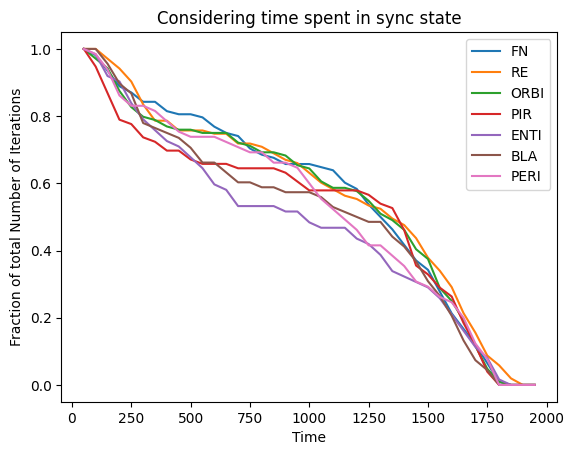

In [6]:
names = [
    "FN",
    "RE",
    "ORBI",
    "PIR",
    "ENTI",
    "BLA",
    "PERI",
]  # List of names to iterate through

for name in names:
    file_path = f"raw/{name}/itr_200.bz2"
    df_itr = reader.data_read_bz2(file_path)

    plot_data = compute_time_spent(df_itr, 2000)
    time_arr = np.array(plot_data["time"])
    count_arr = np.array(plot_data["counts"])
    y = count_arr / count_arr[0]
    plt.plot(time_arr, y, label=name)

plt.title("Considering time spent in sync state")
plt.xlabel("Time")
plt.ylabel("Fraction of total Number of Iterations")
plt.legend()
plt.savefig("sync_time.png")

## Plot of 1000 iteration data


In [ ]:
data_folder = Path(f"../../data/processed")
print(data_folder)
# Use glob to match files with a pattern
# f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_*.bz2"))
print(files)

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]

    df_itr = pd.read_pickle(f, compression="bz2")

    plot_data = compute_time_spent(df_itr, 2000)
    time_arr = np.array(plot_data["time"])
    count_arr = np.array(plot_data["counts"])
    y = count_arr / count_arr[0]
    plt.plot(time_arr, y, label=name_suffix)
    # plt.plot(plot_data['time'],plot_data['counts'],label=name_suffix)

plt.title("Considering time spent in sync state")
plt.xlabel("Time")
plt.ylabel("Number of Iterations")
plt.legend()

../../data/processed
['../../data/processed/itr_bla.bz2', '../../data/processed/itr_fn.bz2', '../../data/processed/itr_pir.bz2', '../../data/processed/itr_re.bz2', '../../data/processed/itr_orbi.bz2', '../../data/processed/itr_enti.bz2', '../../data/processed/itr_peri.bz2']
Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67, 69, 73, 78, 79, 85, 92, 93, 98, 104, 106, 109, 110, 112, 115, 117, 121, 125, 130, 134, 135, 141, 142, 145, 148, 149, 151, 156, 158, 159, 162, 166, 168, 172, 173, 177, 180, 181, 182, 184, 187, 191, 192, 193, 197, 198, 210, 211, 214, 218, 223, 224, 226, 227, 228, 229, 232, 237, 239, 245, 246, 247, 250, 258, 262, 264, 274, 281, 283, 295, 296, 297, 298, 303, 305, 314, 320, 322, 326, 328, 329, 333, 334, 336, 342, 343, 345, 347, 348, 350, 351, 356, 359, 360, 365, 368, 370, 371, 375, 378, 382, 384, 385, 392, 395, 396, 397, 3

## Plot with error bars using SEM as error bar length



#### Steps for bootstrapping

1. Take a random set of 200 iterations for 500 times
2. You will get 500 sets of data points
3. For each data point, 

In [4]:
df = reader.data_read_bz2("results/processed/itr_re.bz2")

In [5]:
df.shape

(40000, 1000)

In [7]:
bs_values = []  # list to store values
for i in range(0, 500):
    df_rand = df.sample(n=200, axis="columns")
    df_rand.columns = list(range(0, 200))
    plot_data = compute_time_spent(df_rand, 2000)
    time_arr = np.array(plot_data["time"])
    count_arr = np.array(plot_data["counts"])
    y = count_arr / count_arr[0]
    bs_values.append(y)

# check = analyse.compute_param(df_rand,0.05)
# check['']


# plot_data=compute_time_spent(df_rand,2000)

Number of transitions / 100 iteration [2, 72, 133]
Number of transition [0, 1, 2, 4, 6, 7, 8, 9, 16, 17, 18, 21, 22, 23, 24, 29, 31, 32, 33, 34, 35, 41, 46, 47, 50, 51, 54, 55, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 71, 72, 73, 75, 78, 80, 83, 85, 87, 97, 98, 99, 100, 101, 105, 106, 108, 112, 114, 116, 117, 118, 119, 120, 122, 125, 126, 127, 128, 132, 133, 136, 137, 138, 139, 140, 142, 146, 148, 149, 150, 152, 154, 156, 158, 161, 165, 167, 169, 170, 171, 177, 179, 181, 184, 186, 187, 189, 191, 193, 194, 195, 196, 197, 198]
Number of transition with more than one transition or a fall back [0, 1, 7, 8, 17, 29, 31, 33, 34, 35, 41, 46, 47, 50, 61, 66, 71, 85, 97, 98, 101, 114, 122, 125, 126, 133, 137, 138, 139, 140, 146, 148, 154, 167, 169, 189, 193, 198]
Number of transitions / 100 iteration [1, 64, 133]
Number of transition [0, 1, 3, 4, 6, 16, 17, 18, 19, 20, 21, 23, 25, 26, 29, 30, 32, 35, 36, 41, 42, 43, 46, 48, 49, 55, 57, 58, 60, 61, 62, 65, 68, 69, 70, 71, 72, 74, 76, 78, 79, 80, 8

In [15]:
len(bs_values)

500

In [8]:
# bs_val_df=pd.DataFrame(bs_values).T
df = pd.DataFrame(bs_values).T
# bs_val_df.head()
# pd.to_pickle(bs_val_df,'../../data/raw/sem_data.bz2',compression='bz2')
# df=reader.data_read_bz2(
#     'raw/sem_data.bz2')

# df.head()

#### Taking average  for each row


In [4]:
df = reader.data_read_bz2("raw/sem_data.bz2")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.968750,0.990099,0.969697,0.970588,0.968421,0.963303,1.00,0.945055,0.956522,0.989583,...,0.981132,0.980769,0.968750,0.990196,0.967391,0.957447,0.981132,0.959596,0.909091,0.979592
2,0.895833,0.930693,0.878788,0.901961,0.873684,0.889908,0.91,0.912088,0.923913,0.916667,...,0.924528,0.942308,0.906250,0.941176,0.923913,0.893617,0.905660,0.909091,0.818182,0.897959
3,0.854167,0.861386,0.848485,0.843137,0.852632,0.834862,0.89,0.868132,0.902174,0.885417,...,0.858491,0.865385,0.885417,0.892157,0.891304,0.851064,0.858491,0.838384,0.784091,0.857143
4,0.760417,0.762376,0.808081,0.764706,0.800000,0.733945,0.83,0.747253,0.815217,0.812500,...,0.801887,0.778846,0.812500,0.784314,0.826087,0.787234,0.783019,0.797980,0.670455,0.785714


### Plot error bars with SEM


In [5]:
mean = df.mean(axis=1)
sem = df.sem(axis=1)

In [9]:
# df=reader.data_read_bz2('processed/itr_re.bz2')
df = pd.read_pickle("../../data/results/processed/itr_re.bz2", compression="bz2")
l = compute_time_spent(df, 2000)
t = l["time"]

Number of transitions / 100 iteration [1, 53, 116, 179, 258, 317, 377, 436, 507, 567, 627]
Number of transition [0, 2, 3, 4, 5, 6, 7, 9, 11, 18, 21, 28, 29, 30, 32, 33, 36, 37, 39, 41, 42, 43, 46, 47, 48, 49, 54, 57, 58, 59, 63, 66, 69, 72, 77, 83, 87, 89, 91, 92, 93, 95, 98, 101, 105, 106, 108, 110, 111, 113, 115, 122, 123, 125, 127, 129, 131, 132, 133, 136, 137, 142, 145, 150, 152, 153, 155, 158, 159, 162, 166, 167, 168, 169, 170, 171, 174, 177, 181, 182, 183, 185, 187, 189, 192, 194, 196, 199, 200, 202, 204, 206, 207, 213, 214, 219, 220, 222, 223, 225, 226, 227, 228, 229, 231, 232, 234, 236, 239, 240, 241, 242, 244, 246, 249, 250, 253, 254, 256, 258, 259, 261, 268, 269, 270, 271, 272, 275, 276, 277, 280, 282, 286, 291, 292, 293, 297, 298, 301, 303, 304, 308, 310, 312, 313, 314, 315, 316, 318, 322, 323, 324, 325, 326, 328, 329, 331, 333, 334, 335, 337, 339, 341, 342, 343, 345, 347, 348, 350, 354, 355, 356, 357, 361, 362, 366, 367, 368, 369, 370, 372, 374, 376, 377, 378, 379, 380, 381

Text(0.5, 1.0, 'Plot of RE with error bars ')

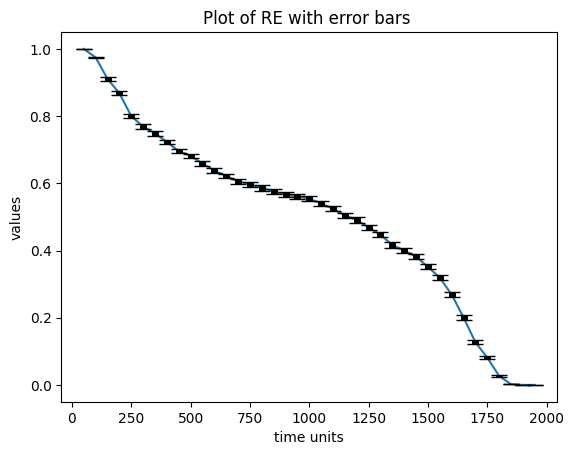

In [19]:
fig, ax = plt.subplots()
ax.plot(t, mean)
ax.errorbar(
    t, mean, yerr=4 * sem, fmt="none", ecolor="k", elinewidth=5, capsize=6, capthick=1
)


plt.xlabel("time units")
plt.ylabel("values")
plt.title("Plot of RE with error bars ")

## Plots with SEM for every NOI


In [ ]:
data_folder = Path(f"../../data/processed")
print(data_folder)
# Use glob to match files with a pattern
# f=pd.read_csv('../../data/')

files = glob.glob(str(data_folder / "itr_*.bz2"))
print(files)

fig, ax = plt.subplots()

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]

    df_itr = pd.read_pickle(f, compression="bz2")
    df = df_itr

    bs_values = []  # list to store values
    for i in range(0, 500):
        df_rand = df.sample(n=200, axis="columns")
        df_rand.columns = list(range(0, 200))
        plot_data = compute_time_spent(df_rand, 2000)
        time_arr = np.array(plot_data["time"])
        count_arr = np.array(plot_data["counts"])
        y = count_arr / count_arr[0]
        bs_values.append(y)

        # coverting bs_values to df

        bs_val_df = pd.DataFrame(bs_values).T

        mean = bs_val_df.mean(axis=1)
        sem = bs_val_df.sem(axis=1)

        l = compute_time_spent(df, 2000)
        t = l["time"]
        # fig,ax = plt.subplots()
    ax.plot(t, mean)
    ax.errorbar(t, mean, yerr=sem, fmt="none", ecolor="k", capsize=3)

plt.title("Considering time spent in sync state")
plt.xlabel("Time")
plt.ylabel("Number of Iterations")
plt.legend()

../../data/processed
['../../data/processed/itr_bla.bz2', '../../data/processed/itr_fn.bz2', '../../data/processed/itr_pir.bz2', '../../data/processed/itr_re.bz2', '../../data/processed/itr_orbi.bz2', '../../data/processed/itr_enti.bz2', '../../data/processed/itr_peri.bz2']
Number of transitions / 100 iteration [0, 38, 76]
Number of transition [1, 4, 5, 9, 12, 14, 15, 21, 24, 25, 28, 29, 30, 41, 42, 44, 45, 49, 52, 53, 63, 66, 67, 72, 75, 76, 79, 88, 97, 106, 108, 111, 113, 115, 116, 122, 130, 131, 133, 134, 139, 140, 150, 152, 153, 155, 157, 159, 164, 167, 172, 174, 175, 180, 181, 184, 186, 190, 191, 196, 198]
Number of transition with more than one transition or a fall back [5, 9, 14, 24, 29, 42, 49, 52, 63, 67, 72, 75, 76, 88, 111, 113, 116, 134, 150, 153, 167, 172, 175, 180, 184, 191]
Number of transitions / 100 iteration [0, 37, 76, 110, 146, 178, 211, 255, 287, 324, 359]
Number of transition [6, 7, 12, 22, 23, 26, 27, 29, 30, 35, 37, 43, 44, 47, 48, 54, 57, 59, 62, 63, 64, 66, 67

In [15]:
sem.shape

(40000,)

In [19]:
df_mean.sem()

0.04306440699500741

In [22]:
len(t)

39

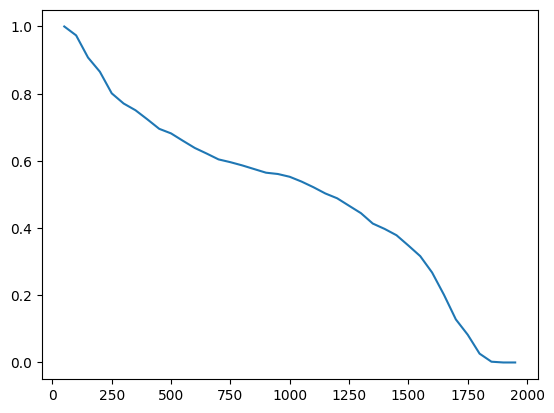

In [24]:
plt.plot(t, df_mean)

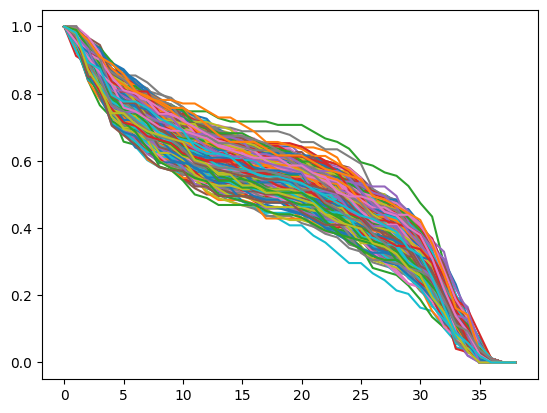

In [16]:
plt.plot(df)

plt.show()